## Ano

In [1]:
# import pandas as pd
# df_list = []

# for year in range(2019,2025):
#     if year == 2019:
#         df_list.append(pd.read_parquet(f"../../data/02_clean/returns_{year-9}_{year}.parquet"))
#     else:
#         df_list.append(pd.read_parquet(f"../../data/02_clean/returns_{year}.parquet"))

In [2]:
# df = pd.concat(df_list)

# for year in range(2019,2025):
#     df.loc[str(year - 1):str(year)].to_parquet(f"../../data/02_clean/returns_{year-1}_{year}.parquet")

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.covariance import LedoitWolf
import seaborn as sns
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
from tqdm import tqdm
import pickle
from functions import (
    corr_matrix, get_network_TMFG, build_and_save_graph
)

years = range(2014,2025)

# modes = {}

# for year in years:
#     modes[f"fast_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/fast_emd.parquet")
#     modes[f"medium_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/medium_emd.parquet")
#     modes[f"slow_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/slow_emd.parquet")

returns = {}
k = 5

for year in years:
    returns[year] = pd.read_parquet(f"../../data/02_clean/returns_new_{year-k+1}_{year}.parquet")
    returns[year] = np.log(1 + returns[year])
    
    # Drop columns with ALL NaNs upfront
    # returns[year] = returns[year].dropna(axis=1, how='all')
    # returns[year].drop(columns=["ABVC", "WKSP"], inplace=True)

# common_cols = set(returns[years[0]].columns)
# for year in years[1:]:
#     common_cols &= set(returns[year].columns)

# common_cols = sorted(list(common_cols))

# # Apply common columns to all years
# for year in years:
#     original_cols = returns[year].shape[1]
#     returns[year] = returns[year][common_cols]
#     print(f"Year {year}: {original_cols} -> {returns[year].shape[1]} columns")

/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.p

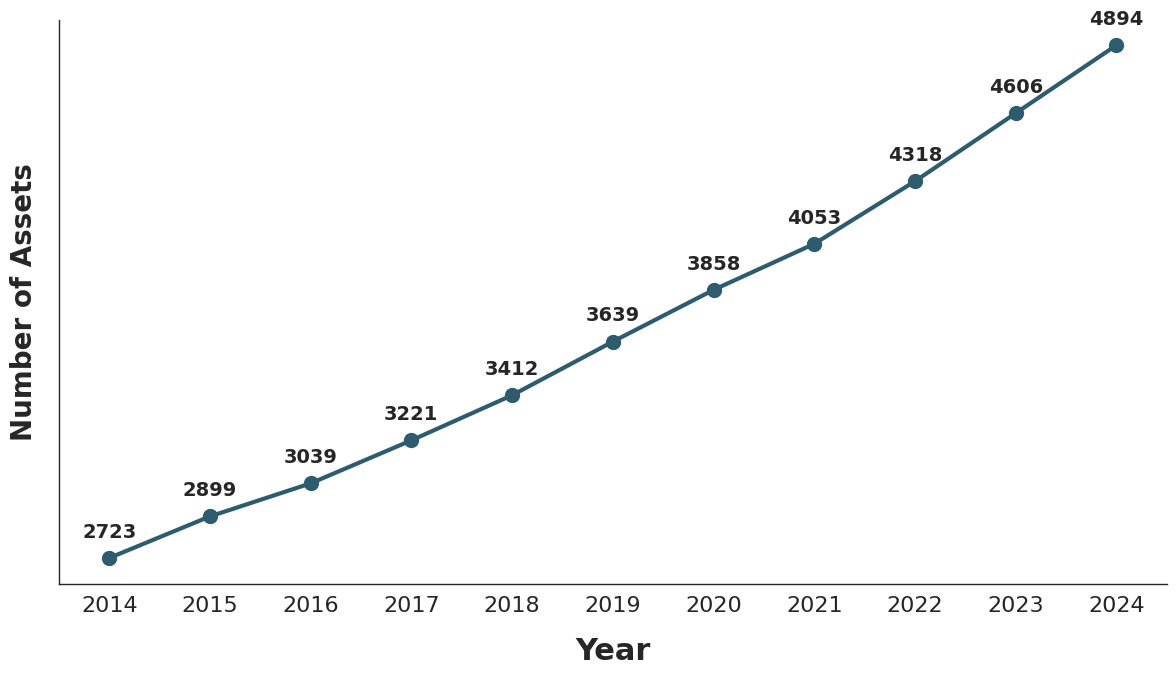

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns 

sns.set_theme(style="white", context="paper", font_scale=1.5)

# 1. More Pythonic approach using list comprehension
n_cols = [returns[year].shape[1] for year in years]

# 2. Set a good figure size (Aumentei levemente para acomodar as fontes maiores)
plt.figure(figsize=(12, 7))

# 3. Plot with markers, custom line width, and color
# (Aumentei a grossura da linha e o tamanho da bolinha)
plt.plot(years, n_cols, marker='o', linestyle='-', linewidth=3, markersize=10, color='#2E5C6E')

# 4. Add clear titles and axis labels (Fontes bem maiores e em negrito para paper)
# Nota: Em artigos muitas vezes não se usa título no gráfico (usa-se o caption do LaTeX), 
# mas se quiser manter, aumentei para 26.
# plt.title('Number of Assets per Year', fontsize=24, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=22, labelpad=15, fontweight='bold')
plt.ylabel('Number of Assets', fontsize=20, labelpad=15, fontweight='bold')

# 5. Ensure X-axis displays whole years
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

# NOVO: Aumentando o tamanho da fonte dos números nos eixos (ticks)
plt.xticks(range(2014,2025), fontsize=16)
plt.yticks([])

# 7. Remove top and right borders (spines) for a cleaner, modern look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 9. Optional: Add the exact value as text above each point
for i, count in enumerate(n_cols):
    plt.annotate(str(count), 
                 (years[i], count), 
                 textcoords="offset points", 
                 xytext=(0, 15), # Afastei um pouco mais por causa da fonte maior
                 ha='center', 
                 fontsize=14,    # Fonte da anotação bem maior
                 fontweight='bold')

# 10. Automatically adjust margins
plt.tight_layout()
plt.savefig("../../figures/n_assets_year.png", dpi=300)
plt.show()

In [5]:
# temp = pd.concat(returns).reset_index().set_index("Date").drop(columns=["level_0"])
# temp.to_csv("../../data/02_clean/returns_clean_401.csv")

In [6]:
# corr = {}

# for year in years:
#     corr[f"corr_fast_{year}"] = corr_matrix(modes[f"fast_{year}"])
#     corr[f"corr_medium_{year}"] = corr_matrix(modes[f"medium_{year}"])
#     corr[f"corr_slow_{year}"] = corr_matrix(modes[f"slow_{year}"])

# corr = {}

# for year in years:
#     corr[year] = corr_matrix(returns[year])

In [7]:
def exponential_weights(t, tau=125):
    """
    Generate exponential weights: w_t = w_0 * exp(-t/tau)
    Normalized so sum(w) = 1
    
    Parameters:
    -----------
    t : int
        Length of time window
    tau : int
        Characteristic time horizon (half-life)
    
    Returns:
    --------
    weights : array
        Exponential weights (most recent = highest weight)
    """
    # Time indices (0 = oldest, t-1 = most recent)
    time_idx = np.arange(t)
    
    # Exponential decay (recent events have higher weight)
    weights = np.exp(-time_idx / tau)
    weights = weights / weights.sum()  # Normalize
    
    # Reverse so most recent has highest weight
    return weights[::-1]

def weighted_correlation(returns, weights):
    """
    Compute weighted Pearson correlation matrix.
    
    Parameters:
    -----------
    returns : DataFrame
        Returns data (rows=time, columns=stocks)
    weights : array
        Time weights (same length as returns)
    
    Returns:
    --------
    corr_matrix : DataFrame
        Weighted correlation matrix
    """
    # Weighted mean
    weighted_mean = (returns * weights[:, None]).sum(axis=0)
    
    # Center the data
    centered = returns - weighted_mean
    
    # Weighted covariance
    weighted_cov = (centered.T @ (centered * weights[:, None])) / weights.sum()
    
    # Convert to correlation
    std = np.sqrt(np.diag(weighted_cov))
    corr = weighted_cov / np.outer(std, std)
    
    return pd.DataFrame(corr, index=returns.columns, columns=returns.columns)


def shrinkage_correlation(corr_matrices):
    """
    Apply shrinkage to average correlation matrix (Eq. 1 from paper).
    
    Averages correlation matrices over time window and shrinks toward
    the grand mean correlation.
    
    Parameters:
    -----------
    corr_matrices : list of DataFrames
        List of correlation matrices over time window
    
    Returns:
    --------
    shrunk_corr : DataFrame
        Shrinkage-adjusted correlation matrix
    """
    # Average the correlation matrices
    avg_corr = sum(corr_matrices) / len(corr_matrices)
    
    # Compute grand mean correlation (off-diagonal only)
    n = len(avg_corr)
    upper_tri_indices = np.triu_indices(n, k=1)
    grand_mean = avg_corr.values[upper_tri_indices].mean()
    
    # Shrinkage formula from paper (Eq. 1)
    shrinkage_factor = 1 / (2 * (len(corr_matrices) + 1))
    
    shrunk = (1 - shrinkage_factor) * avg_corr.values + shrinkage_factor * grand_mean
    
    # Ensure diagonal = 1
    np.fill_diagonal(shrunk, 1.0)
    
    return pd.DataFrame(shrunk, index=avg_corr.index, columns=avg_corr.columns)

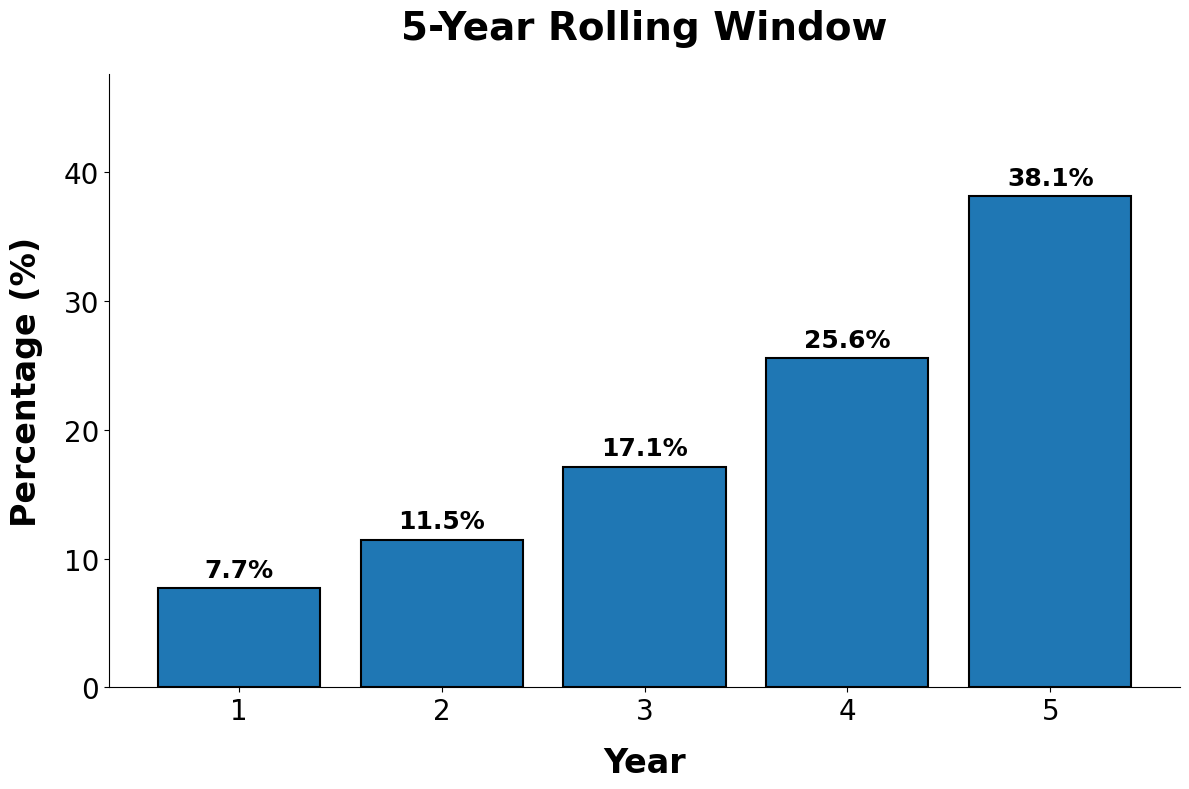

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Ajustado t=5 
w1 = exponential_weights(t=5, tau=2.5)
p1 = 100 * np.array(w1) / np.sum(w1)

# --- FONT SIZE CONFIGURATION (Aumentados para Publicação) ---
TITLE_SIZE = 28 
LABEL_SIZE = 24
TICK_SIZE = 20
ANNOTATION_SIZE = 18

fig, ax = plt.subplots(1, 1, figsize=(12, 8)) 

# ---- Subplot 1 (5-year) ----
# Adicionado edgecolor='black' e ajustado o linewidth para deixar as barras bem desenhadas 
ax.bar(range(len(p1)), p1, linewidth=1.5, edgecolor='black', color='#2E5C6E')

# Título e Labels maiores
ax.set_title("5-Year Rolling Window", fontsize=TITLE_SIZE, fontweight="bold", pad=25)
ax.set_ylabel("Percentage (%)", fontsize=LABEL_SIZE, fontweight="bold", labelpad=15)
ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold", labelpad=15)

ax.set_xticks(range(0, 5))
ax.set_xticklabels(range(1, 6), fontsize=TICK_SIZE)

# Anotações (porcentagens) com fonte maior
for i, v in enumerate(p1):
    # O valor "+ 0.5" afasta a anotação gigante para que ela não fique "esmagada" na barra
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=ANNOTATION_SIZE, fontweight='bold')

# Aumentei o espaço em branco superior (de 1.15 para 1.25) para que o texto gigante caiba sem ser cortado
ax.set_ylim(0, max(p1) * 1.25)

# Configurações globais de ticks no eixo Y
ax.tick_params(axis='y', labelsize=TICK_SIZE)

sns.despine(fig=fig)
plt.tight_layout()
plt.savefig("../../figures/exp_weights.png", dpi=300)
plt.show()

In [9]:
def compute_robust_corr(returns, years, tau, years_back):
    """
    Compute exponentially-weighted, shrunk correlation matrices for each year.

    Parameters
    ----------
    returns    : dict[int, pd.DataFrame]  — daily log-return DataFrames keyed by year
    years      : iterable[int]            — years to process
    tau        : float                    — decay parameter for exponential weights
    years_back : int                      — lookback horizon (>1 = annual windows, 1 = monthly)

    Returns
    -------
    robust_corr : dict[int, pd.DataFrame]
    """
    robust_corr = {}

    if years_back > 1:
        window_days = 252
        n_windows   = years_back
    else:  # years_back == 1
        window_days = 21
        n_windows   = 12

    for year in years:
        # print(f"{year}")
        temp        = returns[year]
        all_columns = temp.dropna(axis=1, how="all").columns
        t_idx       = len(temp) - 1

        corr_matrices_window = []

        for k in range(n_windows):
            window_end   = t_idx - k * window_days
            window_start = window_end - window_days

            if window_start < 0:
                continue

            window       = temp.iloc[window_start:window_end]
            window_clean = window.dropna(axis=1, how="all").dropna(axis=0)

            if len(window_clean) >= window_days * 0.8:
                corr_matrices_window.append(window_clean.corr())

        corr_matrices_window = corr_matrices_window[::-1]  # chronological order

        if not corr_matrices_window:
            print(f"  No valid windows for {year}, skipping.")
            continue

        n_w = len(corr_matrices_window)
        across_weights   = exponential_weights(n_w, tau=tau)
        weighted_avg_corr = np.sum(
            [w * C for w, C in zip(across_weights, corr_matrices_window)],
            axis=0,
        )

        n               = len(weighted_avg_corr)
        upper_tri       = np.triu_indices(n, k=1)
        grand_mean      = weighted_avg_corr[upper_tri].mean()
        shrinkage_factor = 1 / (2 * (n_w + 1))

        shrunk = (1 - shrinkage_factor) * weighted_avg_corr + shrinkage_factor * grand_mean
        np.fill_diagonal(shrunk, 1.0)

        robust_corr[year] = pd.DataFrame(shrunk, index=all_columns, columns=all_columns)

    return robust_corr

In [10]:
def compute_robust_corr_lw(returns_dict: dict, years: range, tau: float, years_back: int) -> dict:
    """
    Compute exponentially-weighted correlation matrices using Ledoit-Wolf 
    shrunk covariances for each year.

    Parameters
    ----------
    returns_dict : dict[int, pd.DataFrame] — daily log-return DataFrames keyed by year
    years        : iterable[int]           — years to process
    tau          : float                   — decay parameter for exponential weights
    years_back   : int                     — lookback horizon (>1 = annual windows, 1 = monthly)

    Returns
    -------
    robust_corr : dict[int, pd.DataFrame]
    """
    robust_corr = {}

    if years_back > 1:
        window_days = 252
        n_windows   = years_back
    else:  # years_back == 1
        window_days = 21
        n_windows   = 12

    # Instantiate the Ledoit-Wolf model
    lw = LedoitWolf()

    for year in years:
        df = returns_dict[year]
        all_columns = df.columns
        t_idx = len(df) - 1

        cov_matrices_window = []

        # 1. Slice windows from most recent to oldest
        for k in range(n_windows):
            window_end   = t_idx - k * window_days
            window_start = window_end - window_days

            if window_start < 0:
                continue

            window_slice = df.iloc[window_start:window_end]
            # Drop rows with NaNs inside this specific window
            window_clean = window_slice.dropna(axis=0)

            if len(window_clean) >= window_days * 0.8:
                # 2. Fit Ledoit-Wolf to get the optimal shrunk covariance matrix
                # scikit-learn handles the optimization of the shrinkage intensity internally
                shrunk_cov = lw.fit(window_clean).covariance_
                cov_matrices_window.append(shrunk_cov)

        # Reverse to chronological order: oldest (index 0) to newest (index n_windows-1)
        cov_matrices_window = cov_matrices_window[::-1]

        if not cov_matrices_window:
            print(f"  No valid windows for {year}, skipping.")
            continue

        # 3. Apply exponential weights to the covariance matrices
        n_w = len(cov_matrices_window)
        across_weights = exponential_weights(n_w, tau=tau)

        weighted_avg_cov = np.sum(
            [w * cov for w, cov in zip(across_weights, cov_matrices_window)],
            axis=0
        )

        # 4. Convert the final weighted covariance matrix into a correlation matrix
        # C_ij = Sigma_ij / sqrt(Sigma_ii * Sigma_jj)
        vols = np.sqrt(np.diag(weighted_avg_cov))
        outer_vols = np.outer(vols, vols)
        final_corr = weighted_avg_cov / outer_vols

        # Force diagonal to exactly 1.0 to prevent floating point precision errors
        np.fill_diagonal(final_corr, 1.0)

        robust_corr[year] = pd.DataFrame(final_corr, index=all_columns, columns=all_columns)

    return robust_corr

In [11]:
# robust_corr_10 = compute_robust_corr_lw(returns_dict=returns, years=range(2015,2025), tau=5, years_back=10)
# robust_corr_1 = compute_robust_corr_lw(returns_dict=returns, years=range(2015,2025), tau=10, years_back=1)
# robust_corr_30 = compute_robust_corr_lw(returns_dict=returns, years=range(2015,2025), tau=15, years_back=30)

robust_corr_5 = compute_robust_corr_lw(returns_dict=returns, years=range(2014,2025), tau=2.5, years_back=5)

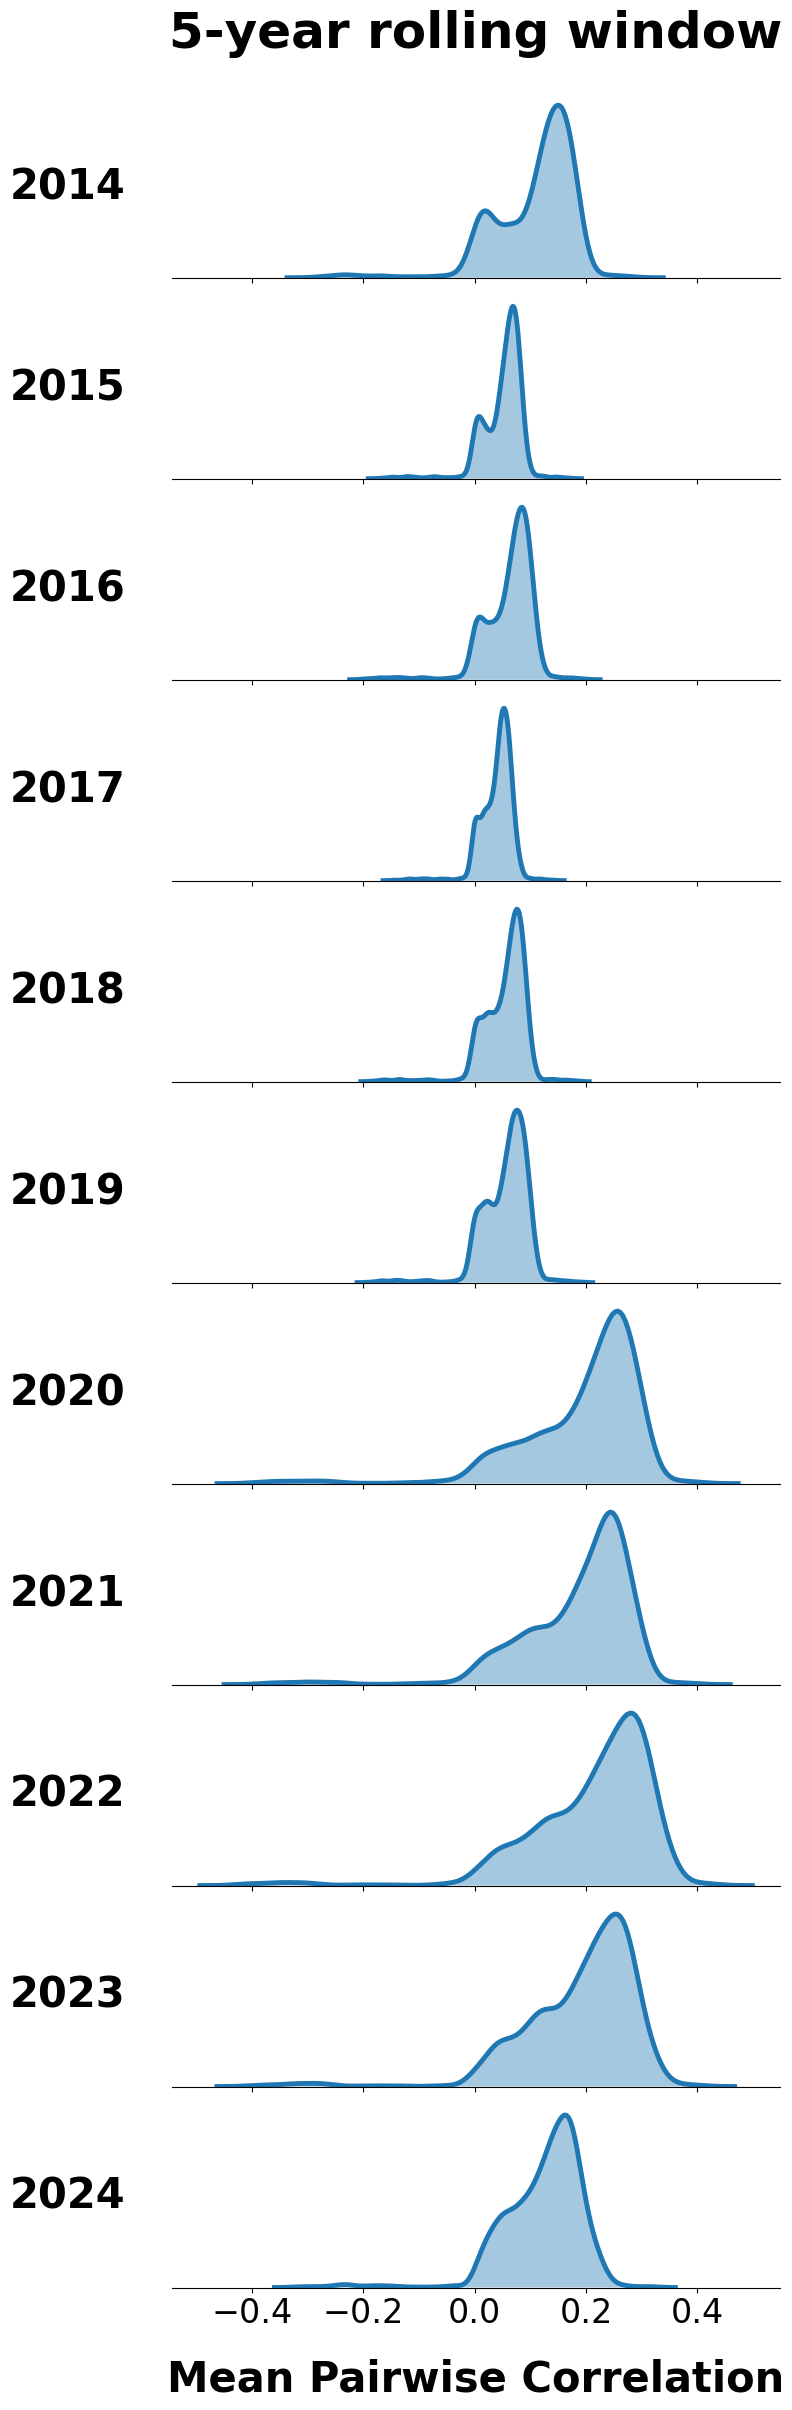

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcula os dados primeiro
# robust_corr_5 = compute_robust_corr_lw(returns_dict=returns, years=range(2014,2025), tau=2.5, years_back=5)

# 2. Dicionário com apenas o robust_corr_5
corr_dicts = {"5-year rolling window": robust_corr_5}

# 3. Alterado para 1 coluna e ajustada a largura (figsize=8). 
fig, axes = plt.subplots(
    len(years), 1, 
    # Aumentei a proporção de altura de 2.0 para 2.2 para dar um respiro extra para os labels grandes
    figsize=(8, len(years) * 2.2), 
    sharex="col",
    squeeze=False 
)

# --- FONT SIZE CONFIGURATION (Tamanhos Gigantes para Artigo Acadêmico) ---
COLUMN_TITLE_SIZE = 36
ROW_LABEL_SIZE = 30
X_LABEL_SIZE = 30
TICK_SIZE = 24

for col_idx, (title, robust_corr) in enumerate(corr_dicts.items()):
    for row_idx, year in enumerate(years):
        ax = axes[row_idx, col_idx]
        data = robust_corr[year].mean()

        # KDE Plot
        sns.kdeplot(data, ax=ax)
        line = ax.get_lines()[0]
        x, y = line.get_data()
        ax.fill_between(x, y, alpha=0.4)
        
        # Deixei o contorno da montanha (kde) bem mais espesso para realçar
        line.set_linewidth(3.5)

        # Year label (Row Label) on the left column
        if col_idx == 0:
            # Aumentei o labelpad de 60 para 75, já que o texto ("2015", etc.) está maior
            ax.set_ylabel(str(year), fontsize=ROW_LABEL_SIZE, fontweight="bold", 
                          rotation=0, labelpad=75, va="center")
        else:
            ax.set_ylabel("")

        # Cleaning up spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.set_yticks([])
        
        # Increase x-tick size for all plots
        ax.tick_params(axis='x', labelsize=TICK_SIZE)

    # Column titles (Top row only)
    axes[0, col_idx].set_title(title, fontsize=COLUMN_TITLE_SIZE, fontweight="bold", pad=35)

    # X-axis labels (Bottom row only)
    # Labelpad aumentado para não encostar nos ticks grandes
    axes[-1, col_idx].set_xlabel("Mean Pairwise Correlation", fontsize=X_LABEL_SIZE, fontweight="bold", labelpad=20)

# Adjust spacing to prevent overlap between larger text elements
# Diminui levemente a sobreposição (de -0.2 para -0.1) para que as curvas não escondam a linha de cima, dado que estão mais grossas
plt.subplots_adjust(hspace=-0.1) 
plt.tight_layout()

plt.savefig("../../figures/ridgeline_5yr.png", dpi=300)
plt.show()

In [20]:
import numpy as np

def get_network_TMFG(corr_matrix):
    """
    Fast O(N^2) TMFG implementation using vectorized NumPy operations.
    Accepts pandas DataFrame or NumPy array.
    """

    # -----------------------------
    # Handle DataFrame input
    # -----------------------------
    if isinstance(corr_matrix, pd.DataFrame):
        labels = corr_matrix.index.to_list()
        C = corr_matrix.values
    else:
        labels = list(range(corr_matrix.shape[0]))
        C = corr_matrix.copy()

    C = np.abs(C)
    n = C.shape[0]

    # Fallback for very small matrices
    if n < 4:
        G = nx.Graph()
        G.add_nodes_from(labels)
        for u in range(n):
            for v in range(u + 1, n):
                G.add_edge(labels[u], labels[v], weight=C[u, v])
        return G

    # -----------------------------
    # Node strength
    # -----------------------------
    strength = C.sum(axis=1)

    # Initial 4-clique: top-4 strengths
    seed = np.argsort(strength)[-4:]

    G = nx.Graph()
    G.add_nodes_from(labels)

    # Add edges of the initial clique
    for i in range(4):
        for j in range(i + 1, 4):
            u, v = seed[i], seed[j]
            G.add_edge(labels[u], labels[v], weight=C[u, v])

    # -----------------------------
    # TMFG growth setup
    # -----------------------------
    # Pre-allocate gains matrix: maximum number of faces is 4 + 3*(n-4)
    max_faces = 4 + 3 * (n - 4)
    gains = np.full((n, max_faces), -np.inf)

    # Initial triangular faces
    faces = [
        (seed[0], seed[1], seed[2]),
        (seed[0], seed[1], seed[3]),
        (seed[0], seed[2], seed[3]),
        (seed[1], seed[2], seed[3])
    ]

    is_remaining = np.ones(n, dtype=bool)
    is_remaining[seed] = False

    # Compute initial gains
    for f_idx, f in enumerate(faces):
        gains[is_remaining, f_idx] = C[is_remaining, f[0]] + C[is_remaining, f[1]] + C[is_remaining, f[2]]

    next_face_idx = 4

    max_gain = np.full(n, -np.inf)
    best_face_idx_for_node = np.full(n, -1, dtype=int)

    rem_nodes = np.where(is_remaining)[0]
    if len(rem_nodes) > 0:
        best_f = np.argmax(gains[rem_nodes, :next_face_idx], axis=1)
        max_gain[rem_nodes] = gains[rem_nodes, best_f]
        best_face_idx_for_node[rem_nodes] = best_f

    # -----------------------------
    # TMFG growth loop
    # -----------------------------
    for _ in range(n - 4):
        # Find the global best remaining node and its best face
        best_node = np.argmax(max_gain)
        best_face_idx = best_face_idx_for_node[best_node]

        i, j, k = faces[best_face_idx]

        # Add edges
        G.add_edge(labels[best_node], labels[i], weight=C[best_node, i])
        G.add_edge(labels[best_node], labels[j], weight=C[best_node, j])
        G.add_edge(labels[best_node], labels[k], weight=C[best_node, k])

        # Update node state
        is_remaining[best_node] = False
        max_gain[best_node] = -np.inf
        gains[best_node, :] = -np.inf
        
        # Mark the face as removed
        gains[:, best_face_idx] = -np.inf

        # 3 new faces generated by the insertion
        new_faces = [
            (best_node, i, j),
            (best_node, i, k),
            (best_node, j, k)
        ]
        new_face_indices = [next_face_idx, next_face_idx + 1, next_face_idx + 2]

        rem_nodes = np.where(is_remaining)[0]
        if len(rem_nodes) == 0:
            break

        # Calculate gains for the new faces
        for f_idx, new_f in zip(new_face_indices, new_faces):
            faces.append(new_f)
            gains[rem_nodes, f_idx] = (
                C[rem_nodes, new_f[0]] + 
                C[rem_nodes, new_f[1]] + 
                C[rem_nodes, new_f[2]]
            )
        
        next_face_idx += 3

        # Update best faces for remaining nodes
        case1_mask = best_face_idx_for_node[rem_nodes] == best_face_idx
        case1_nodes = rem_nodes[case1_mask]
        case2_nodes = rem_nodes[~case1_mask]

        # Case 1: Nodes whose best face was just removed must recompute across ALL active faces
        if len(case1_nodes) > 0:
            best_f_case1 = np.argmax(gains[case1_nodes, :next_face_idx], axis=1)
            max_gain[case1_nodes] = gains[case1_nodes, best_f_case1]
            best_face_idx_for_node[case1_nodes] = best_f_case1

        # Case 2: Other nodes only need to check if any of the 3 new faces are better
        if len(case2_nodes) > 0:
            new_gains = gains[case2_nodes[:, None], new_face_indices]
            new_gains_max = np.max(new_gains, axis=1)
            new_gains_argmax = np.argmax(new_gains, axis=1)

            better_mask = new_gains_max > max_gain[case2_nodes]
            better_nodes = case2_nodes[better_mask]

            if len(better_nodes) > 0:
                max_gain[better_nodes] = new_gains_max[better_mask]
                best_face_idx_for_node[better_nodes] = np.array(new_face_indices)[new_gains_argmax[better_mask]]

    return G

In [21]:
graph = {}

# Lista de todas as tarefas (ano, velocidade)
tasks = [year for year in years]
years_back_list = [5]

robust_corr_dict = {5:robust_corr_5}

# Barra de progresso
for year in tqdm(tasks, desc="Construindo grafos"):
    for years_back in years_back_list:
        # Recupera a matriz de correlação (DataFrame com nomes dos ativos)
        corr_matrix = robust_corr_dict[years_back][year]

        # Constroi o grafo TMFG
        G = get_network_TMFG(corr_matrix)

        # Cria a pasta se não existir e salva
        base_path = f"../../data/04_graphs/{year}_{years_back}"
        os.makedirs(base_path, exist_ok=True)
        file_path = os.path.join(base_path, f"graph.gpickle")
        with open(file_path, "wb") as f:
            pickle.dump(G, f)

        # Armazena no dicionário
        graph[f"graph_{year}"] = G

Construindo grafos: 100%|██████████| 11/11 [00:24<00:00,  2.26s/it]


In [22]:
graph

{'graph_2014': <networkx.classes.graph.Graph at 0x73bb960f5490>,
 'graph_2015': <networkx.classes.graph.Graph at 0x73bbd620e9c0>,
 'graph_2016': <networkx.classes.graph.Graph at 0x73bc00cdaad0>,
 'graph_2017': <networkx.classes.graph.Graph at 0x73bc00cd6e50>,
 'graph_2018': <networkx.classes.graph.Graph at 0x73bb8c30a850>,
 'graph_2019': <networkx.classes.graph.Graph at 0x73bc00ced310>,
 'graph_2020': <networkx.classes.graph.Graph at 0x73bc00ced130>,
 'graph_2021': <networkx.classes.graph.Graph at 0x73bc0037e350>,
 'graph_2022': <networkx.classes.graph.Graph at 0x73bc0037e270>,
 'graph_2023': <networkx.classes.graph.Graph at 0x73bb7815ac30>,
 'graph_2024': <networkx.classes.graph.Graph at 0x73bb79d2bb90>}